# Case Studies: Behavioral Response to a Respiratory Epidemic (Part 3)

## Introduction

In Parts 1 and 2 we ran epidemics on static networks where agent behavior never changed. Here we study a **closed community of 1,000 individuals** and let the model take on extra structure — first an adaptive *behavioral response*, then *contact-rate heterogeneity*.

**Scenario:** a respiratory pathogen spreads through the community. Some infections become severe and require **hospitalization**. As hospitalizations mount, individuals begin to **restrict their contacts** (distancing, staying home, avoiding crowds) — an adaptive, self-limiting feedback loop. On top of this, the population is split into a high-contact front-line minority and a lower-contact general public, and *where* those high-contact individuals sit on the network matters.

Three dimensions drive the model:

1. **Hospitalization dynamics (SIHR model)** — a fraction of infected individuals develop severe disease and are admitted to hospital, where they are isolated (no further transmission) until they recover.
2. **Hospitalization-driven behavior** — each day, individuals who have *not yet* adopted contact-restricting behavior decide whether to adopt it. The probability rises with the share of the community currently hospitalized. Once adopted, the behavior is kept (an absorbing state), and the individual **halves their contacts**.
3. **Contact-rate heterogeneity** — a fraction of the population are high-contact front-line workers and the rest are lower-contact general public. The placement of the front-line minority on the network changes who drives the outbreak. (Sections A and B silently use the homogeneous default `low_risk_factor = 1.0`, so this dimension only "switches on" in Sections C and D.)

### Model compartments

| Symbol | Meaning |
|--------|---------|
| **S** | Susceptible — not yet infected |
| **I** | Infected — infectious, circulating in the community |
| **H** | Hospitalized — severe case, isolated and removed from transmission |
| **R** | Recovered — immune |

### The behavioral feedback loop

> ↑ hospitalizations → ↑ perceived severity → ↑ contact restriction → ↓ transmission → ↓ hospitalizations

### Notebook structure

- **Section A — Baseline SIHR.** Plain SIHR on a small-world network; no behavior, no heterogeneity.
- **Section B — Hospitalization-driven contact restriction.** Layer the adaptive behavioral response on top of A.
- **Section C — Contact heterogeneity.** Switch to a preferential-attachment network and ask *where* the high-contact workers should sit.
- **Section D — Sensitivity sweep.** How sensitive is the outbreak to *how many* high-contact workers there are and *how much* the general public contributes to spread?

## Setup

In [1]:
cd(@__DIR__)

# Per-notebook output directories
const FIGURES_DIR = "figures/part3"
const DATA_DIR    = "data/part3"

mkpath(FIGURES_DIR)
mkpath(DATA_DIR)

using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

using Agents, Graphs, Random, Plots, DataFrames, CSV,
      Statistics, StatsBase, StatsPlots, Measures, CategoricalArrays

include("src/create_graph.jl")

@agent struct Person(GraphAgent)
    status::Symbol       = :S
    days_infected::Int   = 0
    contact_rate::Symbol = :high
end

include("src/initialize.jl")
include("src/agent_step.jl")

function model_step!(model::AgentBasedModel)
    model.susceptible_count  = sum(model[i].status == :S for i in 1:nv(model.graph))
    model.infected_count     = sum(model[i].status == :I for i in 1:nv(model.graph))
    model.hospitalized_count = sum(model[i].status == :H for i in 1:nv(model.graph))
    model.recovered_count    = sum(model[i].status == :R for i in 1:nv(model.graph))
end

  Activating project at `c:\Users\Leonard\julia-workspace\espidam-tutorial-2026`


model_step! (generic function with 1 method)

---
## Section A: Baseline Community Outbreak (SIHR Model)

We begin without any behavioral response, to establish a baseline. All 1,000 individuals sit on a **small-world** network (mean degree ≈ 10), giving high local clustering with a few long-range shortcuts — a reasonable caricature of community contact.

The SIHR model adds a hospitalization stage. With probability `hospitalization_prob`, an infected agent develops severe disease and is admitted to hospital. This is a **single Bernoulli roll per infection, not a per-day hazard** — the roll is made once, on day `hospitalization_day` of infection (default `1`, so by default a newly infected agent may be hospitalized before their first transmission step). So `hospitalization_prob = 0.15` means roughly 15% of infections end up in hospital, *not* 15% per day. Hospitalized agents are isolated (do not transmit) and recover after `days_to_hospital_recovery` days.

We compare:
- **SIR** (`use_hospitalization=false`): everyone circulates until recovery
- **SIHR** (`use_hospitalization=true`): a fraction of infections are removed to hospital

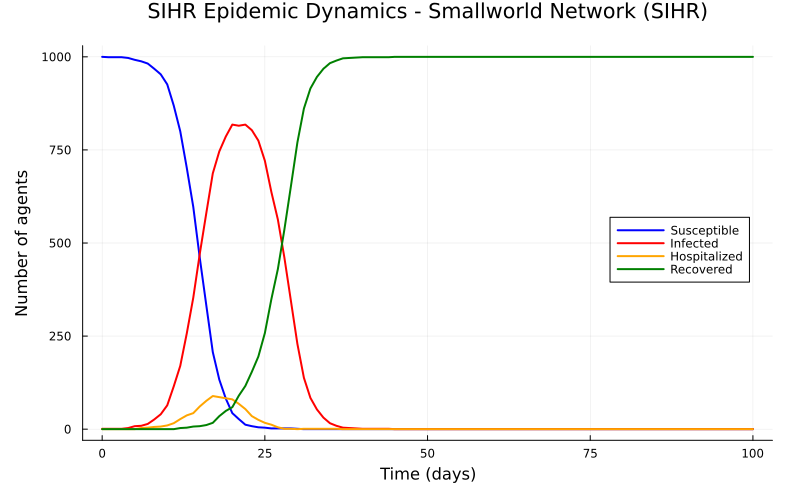

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\baseline_sihr.pdf"

In [2]:
include("src/plotting.jl")

model_sihr = initialize(;
    network_type=:smallworld,
    mean_degree=10,
    patient_zero=:random,
    use_hospitalization=true,
    hospitalization_prob=0.15,
    days_to_hospital_recovery=7,
)

adata = [:status]
mdata = [:susceptible_count, :infected_count, :hospitalized_count, :recovered_count]
_, mdf_sihr = run!(model_sihr, 100; adata, mdata)

p_sihr = plot_epidemic_trajectories(mdf_sihr, :smallworld; title_suffix=" (SIHR)")
display(p_sihr)
savefig(p_sihr, joinpath(FIGURES_DIR, "baseline_sihr.pdf"))

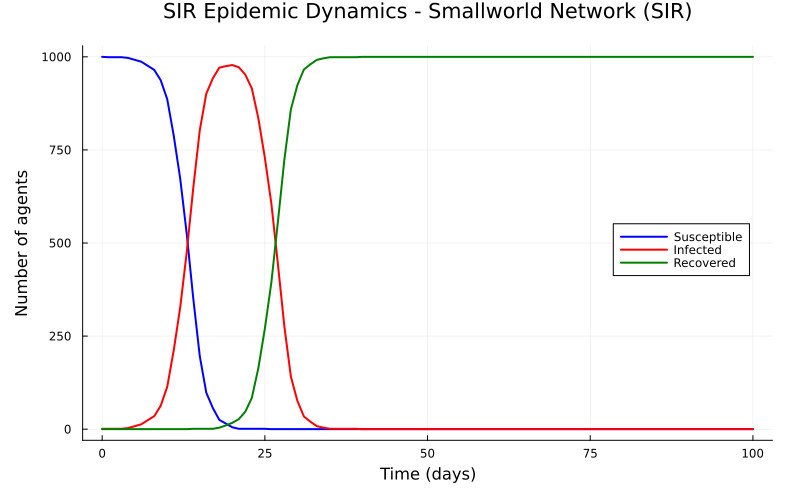

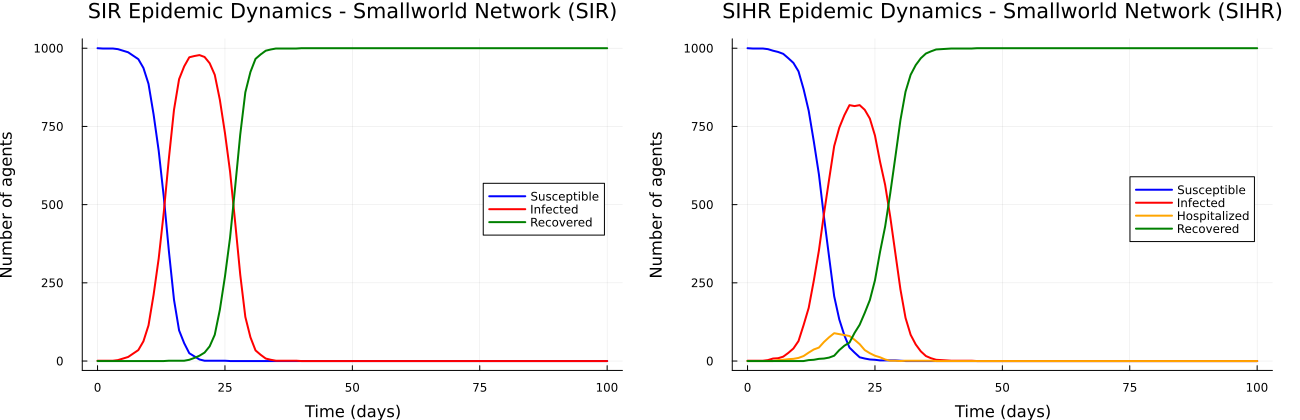

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\sir_vs_sihr.pdf"

In [3]:
model_sir = initialize(;
    network_type=:smallworld,
    mean_degree=10,
    patient_zero=:random,
    use_hospitalization=false,
)

mdata_sir = [:susceptible_count, :infected_count, :recovered_count]
_, mdf_sir = run!(model_sir, 100; adata, mdata=mdata_sir)

p_sir = plot_epidemic_trajectories(mdf_sir, :smallworld; title_suffix=" (SIR)")
display(p_sir)

p_compare = plot(p_sir, p_sihr, layout=(1,2), size=(1300, 420), margin=5Measures.mm)
display(p_compare)
savefig(p_compare, joinpath(FIGURES_DIR, "sir_vs_sihr.pdf"))

**Observation:** In SIHR, a fraction of infected agents are removed to hospital and stop transmitting. This typically lowers the peak infection count and the total circulating infections relative to SIR, while the **hospitalized** compartment tracks the burden on the healthcare system. That hospitalized signal is exactly what will drive the behavioral response in the next section.

---
## Section B: Hospitalization-Driven Contact Restriction

Now we let individuals respond to the outbreak. Each day, every individual who has **not yet** adopted contact-restricting behavior draws a single Bernoulli trial for whether to adopt it. The probability of adopting depends on the fraction of the community currently hospitalized,

$$s = \frac{\text{hospitalized}}{N},$$

through a **logistic** function:

$$p_{\text{adopt}}(s) = \frac{\text{max\_prob}}{1 + e^{-\alpha\,(s - \beta)}}.$$

- **α (`behavior_alpha`)** — *slope*: how sharply adoption switches on as hospitalizations climb.
- **β (`behavior_beta`)** — *mid-point*: the hospitalized fraction at which adoption reaches half of its ceiling. Smaller β → people react earlier.
- **max_prob (`behavior_max_prob`)** — the ceiling on the daily adoption probability.

Adoption is **absorbing**: once someone restricts their contacts they keep doing so, and a restricting individual **halves their contacts** (`contact_reduction = 0.5`). Because a contact involves two people, the transmission probability across a contact is scaled by `(1 - contact_reduction)` for *each* restricting endpoint — so adoption both throttles infectious individuals and protects susceptible ones.

We compare a no-behavior baseline against three parameter sets. The defaults shown below are defined in the next code cell (`behavior_param_sets`) — edit there to tune; labels and downstream cells follow automatically.

| Scenario | α | β | max_prob |
|----------|------|--------|----------|
| Baseline | — (off) | — | — |
| Behavior 1 | 250 | 0.015 | 0.3 |
| Behavior 2 | 300 | 0.0175 | 0.3 |
| Behavior 3 | 400 | 0.020 | 0.3 |

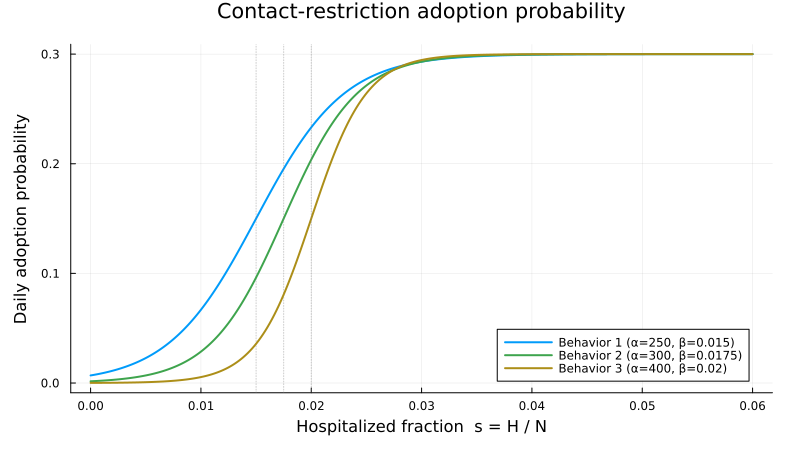

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\adoption_probability_curves.pdf"

In [4]:
# ====================================================================
# Single source of truth — tune the behavioral-response comparison here.
# Edit the entries below (add/remove sets, change α, β, max_prob, or
# contact_reduction). Labels, downstream simulations, and the trajectory
# and boxplot panels all derive from these values automatically.
# ====================================================================
behavior_param_sets = [
    (alpha=250.0, beta=0.015,  max_prob=0.3),
    (alpha=300.0, beta=0.0175, max_prob=0.3),
    (alpha=400.0, beta=0.020,  max_prob=0.3),
]
contact_reduction = 0.5   # same across scenarios; per-adopter cut to each contact's transmission

# Auto-generated labels. Integer-valued floats render without trailing ".0".
_fmt(x) = isinteger(x) ? string(Int(x)) : string(x)
behavior_labels = ["Behavior $i (α=$(_fmt(p.alpha)), β=$(_fmt(p.beta)))"
                   for (i, p) in enumerate(behavior_param_sets)]

# --------------------------------------------------------------------

# Visualize the daily adoption probability as a function of the hospitalized fraction.
# Each curve is the logistic p_adopt(s) for one parameter set.
logistic_adopt(s, α, β, maxp) = maxp / (1 + exp(-α * (s - β)))

s_grid = range(0, 0.06; length=300)   # hospitalized fraction, 0% to 6%
p_curves = plot(xlabel="Hospitalized fraction  s = H / N",
    ylabel="Daily adoption probability",
    title="Contact-restriction adoption probability",
    legend=:bottomright, size=(800, 450), margin=5Measures.mm)

for (label, params) in zip(behavior_labels, behavior_param_sets)
    plot!(p_curves, s_grid, logistic_adopt.(s_grid, params.alpha, params.beta, params.max_prob);
        label=label, linewidth=2)
    vline!(p_curves, [params.beta]; label="", linestyle=:dot, color=:gray, alpha=0.4)
end

display(p_curves)
savefig(p_curves, joinpath(FIGURES_DIR, "adoption_probability_curves.pdf"))

### Running the scenarios

We now run the full model (SIHR + behavior) for the baseline and the three parameter sets, each over many random seeds, and compare the epidemic trajectories. The behavioral feedback should bend the curves: as the hospitalized compartment grows, more individuals restrict their contacts, throttling transmission and flattening the outbreak.

In [5]:
include("src/run_simulations.jl")
include("src/plotting.jl")

# Baseline (no behavior) prepended to the per-set entries from `behavior_param_sets`.
# Labels match the adoption-curve cell — see that cell to tune α, β, max_prob.
scenarios = vcat(
    [(label="Baseline (no behavior)", use_behavior=false, alpha=0.0, beta=0.0, max_prob=0.0)],
    [(label=label, use_behavior=true,
      alpha=params.alpha, beta=params.beta, max_prob=params.max_prob)
     for (label, params) in zip(behavior_labels, behavior_param_sets)]
)

results_behavior = Dict{String,Any}()
for s in scenarios
    println("Running: $(s.label) ...")
    results_behavior[s.label] = run_simulations(;
        network_type=:smallworld,
        mean_degree=10,
        patient_zero=:random,
        use_hospitalization=true,
        hospitalization_prob=0.15,
        days_to_hospital_recovery=7,
        use_behavior_adoption=s.use_behavior,
        behavior_alpha=s.alpha,
        behavior_beta=s.beta,
        behavior_max_prob=s.max_prob,
        contact_reduction=contact_reduction,
    )
end
println("Done.")

Running: Baseline (no behavior) ...
Running: Behavior 1 (α=250, β=0.015) ...
Running: Behavior 2 (α=300, β=0.0175) ...
Running: Behavior 3 (α=400, β=0.02) ...
Done.


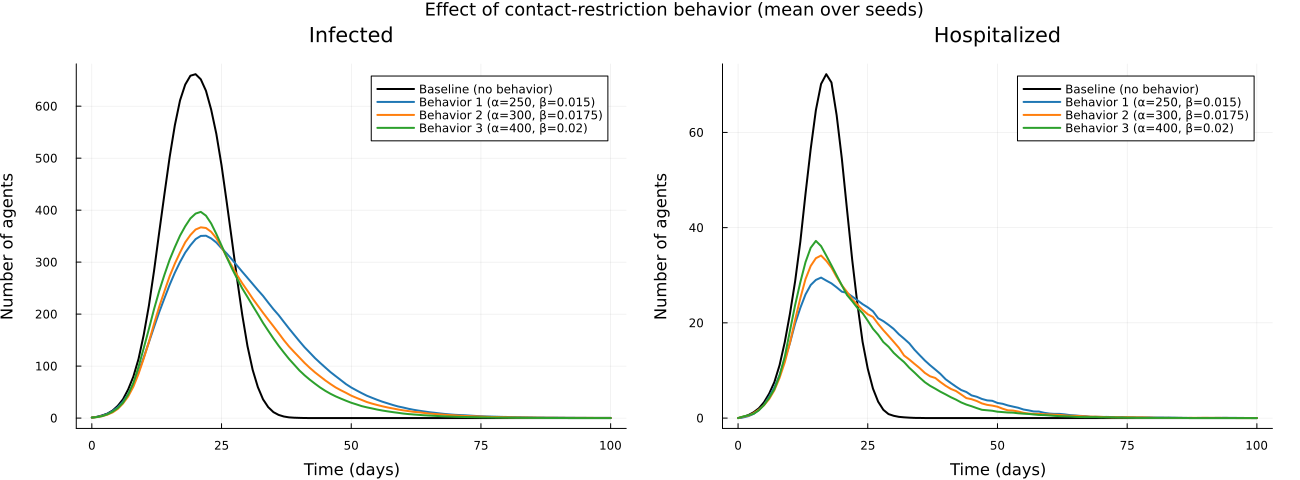

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\behavior_trajectories.pdf"

In [6]:
# Mean infected and hospitalized trajectories across seeds, one curve per scenario.
scenario_labels = [s.label for s in scenarios]
# Baseline = black for visual distinctness; behaviors auto-pick from a 10-color palette,
# so adding/removing entries to `behavior_param_sets` just works (up to 10 scenarios).
scenario_colors = vcat(:black, [palette(:tab10)[i] for i in 1:length(behavior_param_sets)])

p_inf  = plot(title="Infected",     xlabel="Time (days)", ylabel="Number of agents", legend=:topright)
p_hosp = plot(title="Hospitalized", xlabel="Time (days)", ylabel="Number of agents", legend=:topright)

for (label, col) in zip(scenario_labels, scenario_colors)
    mdf = results_behavior[label]
    mean_traj = combine(groupby(mdf, :time),
        :infected_count     => mean => :mean_inf,
        :hospitalized_count => mean => :mean_hosp,
    )
    sort!(mean_traj, :time)
    plot!(p_inf,  mean_traj.time, mean_traj.mean_inf;  label=label, linewidth=2, color=col)
    plot!(p_hosp, mean_traj.time, mean_traj.mean_hosp; label=label, linewidth=2, color=col)
end

p_traj = plot(p_inf, p_hosp, layout=(1,2), size=(1300, 480), margin=5Measures.mm,
    plot_title="Effect of contact-restriction behavior (mean over seeds)",
    plot_titlefontsize=12)
display(p_traj)
savefig(p_traj, joinpath(FIGURES_DIR, "behavior_trajectories.pdf"))

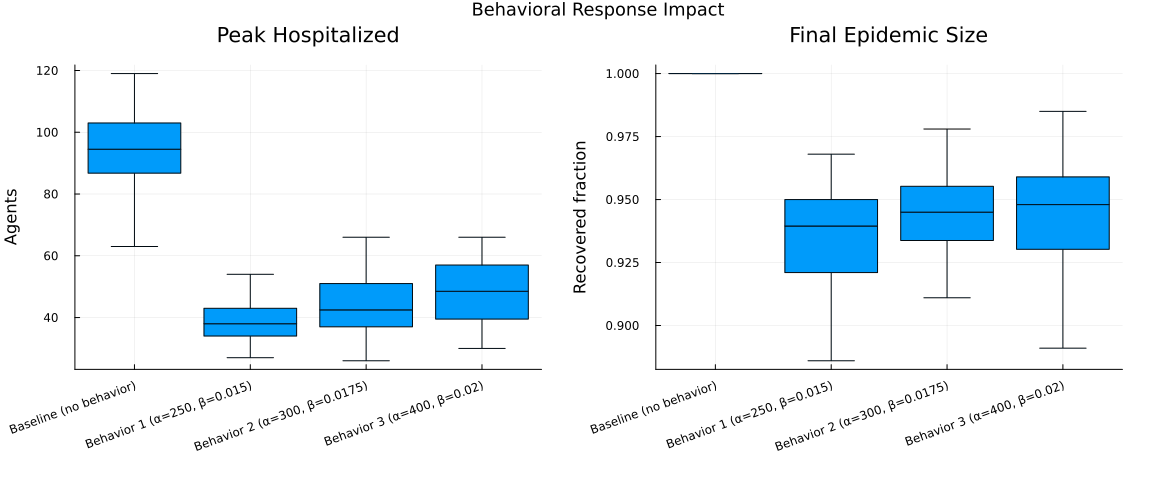

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\behavior_boxes.pdf"

In [7]:
# Per-seed summary metrics: peak hospitalized burden and final epidemic size.
peak_hosp_beh  = DataFrame(value=Float64[], scenario=String[])
final_size_beh = DataFrame(value=Float64[], scenario=String[])

for label in scenario_labels
    mdf = results_behavior[label]
    for gdf in groupby(mdf, :seed)
        last_row = last(gdf)
        total = last_row.susceptible_count + last_row.infected_count +
                last_row.hospitalized_count + last_row.recovered_count
        push!(peak_hosp_beh,  (maximum(gdf.hospitalized_count), label))
        push!(final_size_beh, (last_row.recovered_count / total, label))
    end
end

# Ordered categorical so the boxplots follow the scenario order
for df in (peak_hosp_beh, final_size_beh)
    df.scenario = CategoricalArray(df.scenario; ordered=true, levels=scenario_labels)
end

bp_peak = boxplot(peak_hosp_beh.scenario, peak_hosp_beh.value;
    title="Peak Hospitalized", ylabel="Agents", legend=false,
    outliers=false, xrotation=20, margin=5Measures.mm)
bp_size = boxplot(final_size_beh.scenario, final_size_beh.value;
    title="Final Epidemic Size", ylabel="Recovered fraction", legend=false,
    outliers=false, xrotation=20, margin=5Measures.mm)

p_boxes = plot(bp_peak, bp_size, layout=(1,2), size=(1150, 480),
    plot_title="Behavioral Response Impact", plot_titlefontsize=12,
    bottom_margin=16Measures.mm)
display(p_boxes)
savefig(p_boxes, joinpath(FIGURES_DIR, "behavior_boxes.pdf"))

---
## Section B — Interpretation

*(Reading C and D next? These bullets summarize Section B specifically — the contact-heterogeneity sections that follow have their own dynamics.)*

- **The behavioral feedback flattens the outbreak.** Once the hospitalized fraction climbs past the mid-point β, adoption of contact restriction accelerates, transmission is throttled, and the infected and hospitalized peaks drop relative to the baseline.
- **Earlier, sharper responses help most.** A smaller β (people react at a lower hospitalization level) and a larger α (a sharper switch) bring the response forward and cut the peak further. Comparing the three parameter sets, the one that triggers earliest leaves the most susceptibles uninfected (smallest final size).
- **Self-limiting, not eliminating.** Because adoption is capped at `max_prob` per day and only halves contacts, the behavior slows and shrinks the epidemic but does not stop it outright — a realistic feature of voluntary, severity-driven distancing. As the outbreak recedes the hospitalized signal falls, but already-adopted individuals keep restricting (the state is absorbing).

### Things to try
- Raise `behavior_max_prob` toward `1.0`, or lower `behavior_beta`, and watch the peak collapse.
- Increase `contact_reduction` toward `1.0` (a stronger personal cut) and weigh it against broader-but-weaker adoption.
- Change `mean_degree` or switch `patient_zero` to `:maxdegree` to see how the contact structure interacts with the behavioral response.

---
## Section C: Contact Heterogeneity — Where Are the High-Contact Workers?

Sections A and B treated the community as **transmission-homogeneous**: every agent transmitted at the same rate (`low_risk_factor = 1.0`, the default). The model has actually carried two contact groups all along — the `contact_rate` field on each agent can be `:high` or `:low`, populated via `fraction_high_contact` and `high_contact` — but with `low_risk_factor = 1.0` the two groups are interchangeable. We now engage this dimension.

A realistic community is not homogeneous. A minority of front-line/essential workers (retail, transit, delivery, care work) have *many* daily contacts, while most of the population has *fewer* — they work from home, shop online, and keep to smaller circles. We split the population accordingly: 10% are high-contact front-line workers (`contact_rate = :high`), 90% are lower-contact members of the general public (`contact_rate = :low`), and the general public transmits at `low_risk_factor = 0.3` times the front-line rate.

To make the **placement** of high-contact workers on the contact network matter, we switch from the small-world network used so far to a **preferential-attachment** network where a few highly-connected hubs bridge many smaller clusters. On the small-world network all nodes have similar degree, so where the high-contact workers sit makes little difference; on preferential attachment the hubs are pronounced and placement is decisive. We leave the behavioral response off here to isolate the structural effect.

The key question: **does the placement of high-contact workers on the network change the outbreak?**

We compare three placement strategies:
- `:random` — high-contact workers placed at random nodes
- `:maxdegree` — placed at the most-connected nodes (hubs)
- `:maxbetweenness` — placed at nodes on the most shortest paths (bridges)

The hypothesis: placing high-contact individuals at central nodes creates super-spreaders and accelerates the epidemic.

In [8]:
include("src/run_simulations.jl")

# Common parameters; only the `high_contact` placement strategy varies between runs.
# Behavioral response is left off here to isolate the structural effect of placement.
placement_params = (
    network_type        = :preferential,
    mean_degree         = 10,
    fraction_high_contact = 0.1,
    low_risk_factor     = 0.3,
    patient_zero        = :maxdegree,
    use_hospitalization = true,
    hospitalization_prob = 0.15,
    days_to_hospital_recovery = 7,
)

results_placement = Dict{Symbol,Any}()
for strategy in [:random, :maxdegree, :maxbetweenness]
    println("Running simulations for high_contact=$(strategy) ...")
    results_placement[strategy] = run_simulations(;
        placement_params...,
        high_contact=strategy,
    )
end
println("Done.")

Running simulations for high_contact=random ...
Running simulations for high_contact=maxdegree ...
Running simulations for high_contact=maxbetweenness ...
Done.


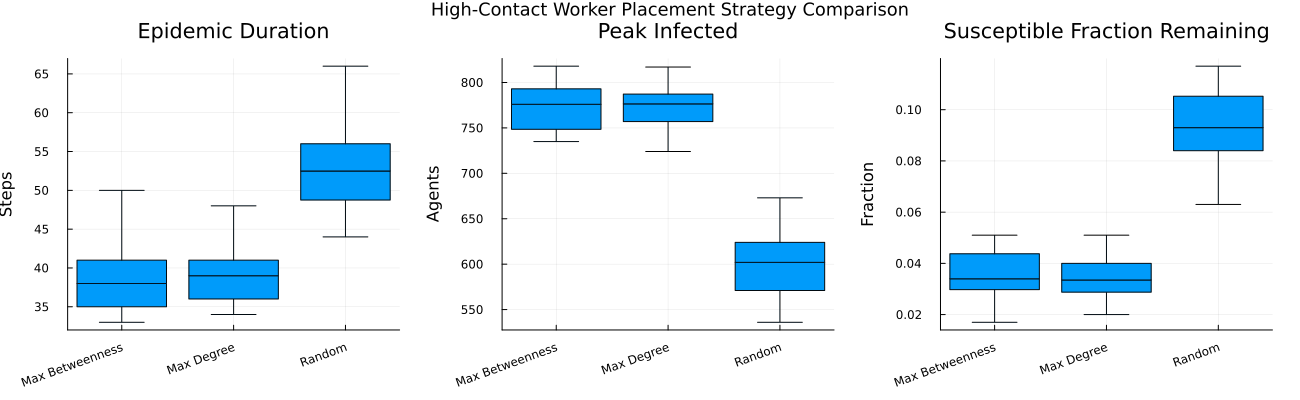

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\placement_strategy.pdf"

In [9]:
placement_labels = ["Random", "Max Degree", "Max Betweenness"]
strategies       = [:random, :maxdegree, :maxbetweenness]

# Per-seed summary metrics for each placement strategy
duration_data = DataFrame(value=Float64[], placement=String[])
maxinf_data   = DataFrame(value=Float64[], placement=String[])
sfr_data      = DataFrame(value=Float64[], placement=String[])

for (strategy, label) in zip(strategies, placement_labels)
    mdf = results_placement[strategy]
    for gdf in groupby(mdf, :seed)
        first_inf = findfirst(gdf.infected_count .> 0)
        last_inf  = findlast(gdf.infected_count .> 0)
        dur = isnothing(last_inf) ? nrow(gdf) : last_inf - first_inf + 1
        push!(duration_data, (dur, label))
        push!(maxinf_data,   (maximum(gdf.infected_count), label))
        last_row = last(gdf)
        total = last_row.susceptible_count + last_row.infected_count +
                last_row.hospitalized_count + last_row.recovered_count
        push!(sfr_data, (last_row.susceptible_count / total, label))
    end
end

bp1 = boxplot(duration_data.placement, duration_data.value;
    title="Epidemic Duration", ylabel="Steps", legend=false,
    outliers=false, xrotation=20, margin=5Measures.mm)
bp2 = boxplot(maxinf_data.placement, maxinf_data.value;
    title="Peak Infected", ylabel="Agents", legend=false,
    outliers=false, xrotation=20, margin=5Measures.mm)
bp3 = boxplot(sfr_data.placement, sfr_data.value;
    title="Susceptible Fraction Remaining", ylabel="Fraction", legend=false,
    outliers=false, xrotation=20, margin=5Measures.mm)

p_placement = plot(bp1, bp2, bp3, layout=(1,3), size=(1300, 400),
    plot_title="High-Contact Worker Placement Strategy Comparison",
    plot_titlefontsize=12, bottom_margin=10Measures.mm)
display(p_placement)
savefig(p_placement, joinpath(FIGURES_DIR, "placement_strategy.pdf"))

---
## Section D: Sensitivity to High-Contact Fraction and Public Transmission Rate

Having established that **where** the high-contact workers sit on the network matters (Section C), we now ask **how many** of them there should be, and **how much** the rest of the public contributes to spread. We sweep two parameters:

1. **High-contact fraction** (`fraction_high_contact`): what share of the population are front-line workers?
2. **Public transmission rate** (`low_risk_factor`): how much does the lower-contact general public contribute to spread, relative to front-line workers?

We keep the preferential-attachment network from Section C with high-contact workers placed at the hubs (`high_contact=:maxdegree`) and look at the **mean peak number of hospitalized agents** — a proxy for healthcare-system burden.

In [10]:
# Parameter sweep: high-contact fraction × public transmission multiplier
high_contact_fractions = [0.05, 0.10, 0.15, 0.20, 0.25]
low_risk_factors       = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

peak_hosp_matrix = zeros(length(high_contact_fractions), length(low_risk_factors))

for (i, fhc) in enumerate(high_contact_fractions)
    for (j, lrf) in enumerate(low_risk_factors)
        println("fraction_high_contact=$(fhc), low_risk_factor=$(lrf)")
        mdf = run_simulations(;
            network_type=:preferential,
            mean_degree=10,
            high_contact=:maxdegree,
            fraction_high_contact=Float64(fhc),
            low_risk_factor=Float64(lrf),
            patient_zero=:maxdegree,
            use_hospitalization=true,
            hospitalization_prob=0.15,
            days_to_hospital_recovery=7,
        )
        # Mean peak hospitalized across seeds
        peak_hosp_matrix[i, j] = mean(
            combine(groupby(mdf, :seed), :hospitalized_count => maximum => :peak).peak
        )
    end
end
println("Sweep complete.")

fraction_high_contact=0.05, low_risk_factor=0.1
fraction_high_contact=0.05, low_risk_factor=0.2
fraction_high_contact=0.05, low_risk_factor=0.4
fraction_high_contact=0.05, low_risk_factor=0.6
fraction_high_contact=0.05, low_risk_factor=0.8
fraction_high_contact=0.05, low_risk_factor=1.0
fraction_high_contact=0.1, low_risk_factor=0.1
fraction_high_contact=0.1, low_risk_factor=0.2
fraction_high_contact=0.1, low_risk_factor=0.4
fraction_high_contact=0.1, low_risk_factor=0.6
fraction_high_contact=0.1, low_risk_factor=0.8
fraction_high_contact=0.1, low_risk_factor=1.0
fraction_high_contact=0.15, low_risk_factor=0.1
fraction_high_contact=0.15, low_risk_factor=0.2
fraction_high_contact=0.15, low_risk_factor=0.4
fraction_high_contact=0.15, low_risk_factor=0.6
fraction_high_contact=0.15, low_risk_factor=0.8
fraction_high_contact=0.15, low_risk_factor=1.0
fraction_high_contact=0.2, low_risk_factor=0.1
fraction_high_contact=0.2, low_risk_factor=0.2
fraction_high_contact=0.2, low_risk_factor=0.4
f

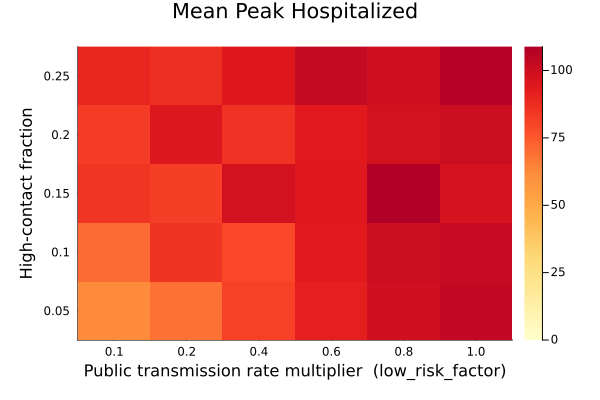

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\peak_hospitalized_heatmap.pdf"

In [11]:
p_heatmap = heatmap(
    string.(low_risk_factors), string.(high_contact_fractions), peak_hosp_matrix;
    xlabel="Public transmission rate multiplier  (low_risk_factor)",
    ylabel="High-contact fraction",
    title="Mean Peak Hospitalized",
    color=:YlOrRd,
    size=(600, 400),
    margin=5Measures.mm,
    clims=(0, maximum(peak_hosp_matrix)),
)
display(p_heatmap)
savefig(p_heatmap, joinpath(FIGURES_DIR, "peak_hospitalized_heatmap.pdf"))